<h1>MonReader

We collected page flipping video from smart phones and labelled them as flipping and not flipping.

We clipped the videos as short videos and labelled them as flipping or not flipping. The extracted frames are then saved to disk in a sequential order with the following naming structure: VideoID_FrameNumber

#### **Goal(s):**

Predict if the page is being flipped using a single image.

#### **Success Metrics:**

Evaluate model performance based on F1 score, the higher the better.

#### **Current Challenges:**

Predict if a given sequence of images contains an action of flipping.

In [1]:
import numpy as np
import pandas as pd

In [2]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

<h2>EDA

<h3>Counting the data

Each image in the flip and notflip folders has the following naming/numbering convention: 00wx_0000000yz.jpg, where wx is the clip number, and yz is the frame number. 

Let's count the number of clips, and the number of frames in each clip:

In [3]:
def count_frames_per_clip(data_dir) -> pd.DataFrame:
    """
    Count frames per clip in the dataset.

    Expects: data_dir / <split> / <label> / <VideoID>_<FrameNumber>.jpg
    e.g.     data/raw / training  / flip   / 0001_000000020.jpg

    VideoID numbering resets inside each (split, label) folder, so a clip is
    only uniquely identified by the (split, label, video_id) triple, not by
    video_id alone.

    Returns one row per clip: split, label, video_id, frame_count,
    min_frame, max_frame (raw frame numbers aren't contiguous within a clip,
    so max_frame - min_frame + 1 can be larger than frame_count).
    """
    data_dir = Path(data_dir)
    rows = []
    for split_dir in sorted(p for p in data_dir.iterdir() if p.is_dir()):
        for label_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
            counts, frame_min, frame_max = {}, {}, {}
            for img_path in label_dir.glob("*.jpg"):
                video_id, _, frame_str = img_path.stem.partition("_")
                frame_number = int(frame_str)
                counts[video_id] = counts.get(video_id, 0) + 1
                frame_min[video_id] = min(frame_min.get(video_id, frame_number), frame_number)
                frame_max[video_id] = max(frame_max.get(video_id, frame_number), frame_number)
            for video_id, frame_count in counts.items():
                rows.append({
                    "split": split_dir.name,
                    "label": label_dir.name,
                    "video_id": video_id,
                    "frame_count": frame_count,
                    "min_frame": frame_min[video_id],
                    "max_frame": frame_max[video_id],
                })
    return (
        pd.DataFrame(rows)
        .sort_values(["split", "label", "video_id"])
        .reset_index(drop=True)
    )


# usage
df = count_frames_per_clip(RAW_DATA_DIR)
print(df.groupby(["split", "label"])["frame_count"].agg(["count", "mean", "min", "max"]))

                  count       mean  min  max
split    label                              
testing  flip        63   4.603175    1   12
         notflip     52   5.903846    2   11
training flip        65  17.876923    7   43
         notflip     52  23.653846    6   28


- 'Count' is the number of clips.
- 'Mean' is the average number of frames per clip, and 'min' & 'max' are the number of frames present in the smallest and largest clips respectively.


- Looking at the 'flip' and 'notflip' counts in the training split, there is a class imbalance present, with more 'flip' than 'notflip'

<h3>Viewing Image Format

Take an image from the dataset:

In [4]:
import cv2

image_name = '0001_000000001.jpg'
img = cv2.imread(RAW_DATA_DIR/"training/notflip"/image_name)
img.shape

(1920, 1080, 3)

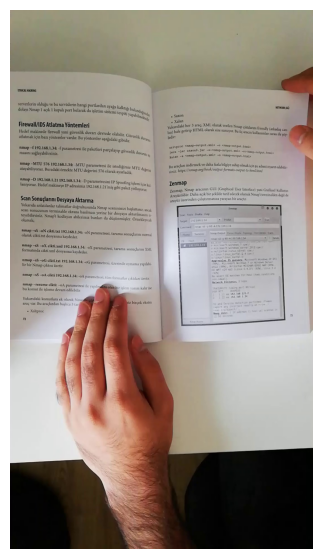

In [5]:
# View the image:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

So it appears to be a 1920x108 resolution RGB image. The model needs to be able to distinguish between flip and not-flip which I would argue shouldn't be dependent on color. It may be batter to convert to grayscale to reduce the size of the matrix constituting the images:

In [6]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img.shape

(1920, 1080)

In [7]:
type(gray_img)

numpy.ndarray

numpy array is a good format for neural nets

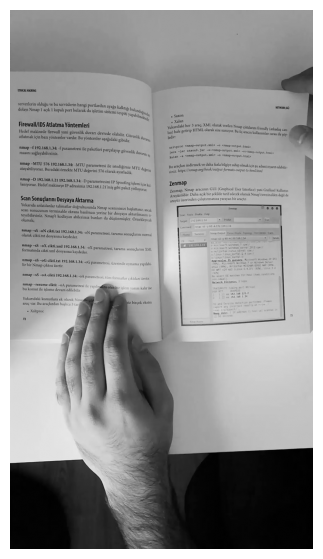

In [8]:
plt.figure(figsize=(12, 7))
plt.imshow(gray_img, cmap="gray") #Default imshow colour is green. Specify gray here
plt.axis("off")
plt.show()

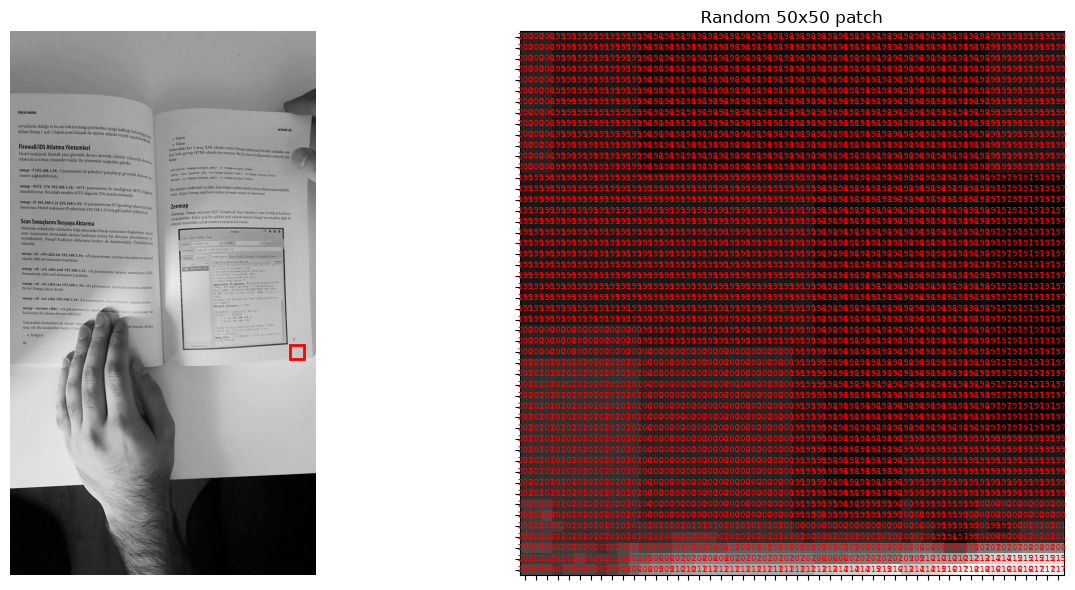

Patch location (row, col): (1107, 989)
Patch shape: (50, 50)
Pixel value range in patch: 197 - 218
Data type: uint8


In [10]:
# Viewing pixel values for a random 50x50 patch from an image

patch_size = 50
h, w = gray_img.shape

# Random top-left corner for 20x20 patch
start_row = np.random.randint(0, h - patch_size + 1)
start_col = np.random.randint(0, w - patch_size + 1)

patch = gray_img[start_row:start_row + patch_size, start_col:start_col + patch_size]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Full image with selected patch highlighted
ax1.imshow(gray_img, cmap='gray')
ax1.axis('off')
rect = plt.Rectangle((start_col, start_row), patch_size, patch_size,
                     fill=False, edgecolor='red', linewidth=2)
ax1.add_patch(rect)

# 20x20 patch with pixel annotations
ax2.imshow(patch, cmap='gray')
ax2.set_title(f'Random {patch_size}x{patch_size} patch')
ax2.set_xticks(range(patch_size))
ax2.set_yticks(range(patch_size))
ax2.set_xticklabels([])
ax2.set_yticklabels([])

for i in range(patch_size):
    for j in range(patch_size):
        ax2.text(j, i, int(patch[i, j]), ha="center", va="center", color="red", fontsize=6)

plt.tight_layout()
plt.show()

print(f"Patch location (row, col): ({start_row}, {start_col})")
print(f"Patch shape: {patch.shape}")
print(f"Pixel value range in patch: {patch.min()} - {patch.max()}")
print(f"Data type: {patch.dtype}")

# Hard to plot the whole image as theyare quite large and detailed. We are viewing a small area here.

I believe brightness values range from 0-255

In terms of training a model we have two options:
1. Single Frame Method (SFM): Feed all the frames as their own data rows allowing the model to learn and predict page flipping based on single frames.
2. Multiple Frame Method (MFM): Aggregate all the frames of a clip into a single 'row' for each clip allowing the model to learn and predict page flipping based on a clip (multiple frames).